In [4]:
from pathlib import Path

import sys

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

print(f"Raíz del proyecto: {PROJECT_ROOT}")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from experimento_aa import (
    prepare_aa_data,
    train_aa_and_reconstruct,
    calculate_aa_metrics,
)

Raíz del proyecto: c:\Users\adanm\Code\tesis
Using NumPy backend


In [3]:
DATASET_REFERENCIA = "interpolacion_50"
NORMALIZACIONES = (
    "minmax",
    "centered",
    "zscore",
)

K_SELECCIONADO = 5
INICIALIZACION_AA = "pca_convex_hull_furthest_sum"

N_ESTRELLAS_SUBMUESTRA = 5000
SEMILLA_MUESTREO = 42
SEMILLA_MODELO = 0

In [5]:

_, _, metadata_train_referencia, _ = prepare_aa_data(
    dataset=DATASET_REFERENCIA,
    normalizacion="minmax",
)

subtipos_por_estrella = (
    metadata_train_referencia[
        ["star_id_base", "subtipo_rrlyrae"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

estrellas_submuestra, _ = train_test_split(
    subtipos_por_estrella,
    train_size=N_ESTRELLAS_SUBMUESTRA,
    random_state=SEMILLA_MUESTREO,
    stratify=subtipos_por_estrella["subtipo_rrlyrae"],
)

ids_submuestra = set(
    estrellas_submuestra["star_id_base"]
)

print(f"Estrellas seleccionadas: {len(ids_submuestra):,}")
print("\nEstrellas por subtipo:")
print(
    estrellas_submuestra[
        "subtipo_rrlyrae"
    ].value_counts()
)

Estrellas seleccionadas: 5,000

Estrellas por subtipo:
subtipo_rrlyrae
RRab    3535
RRc     1299
RRd      166
Name: count, dtype: int64


In [6]:
resultados_normalizacion = []
arquetipos_por_normalizacion = {}


for normalizacion in NORMALIZACIONES:
    print(
        "\n"
        + "=" * 60
        + f"\nNormalización: {normalizacion}"
        + "\n"
        + "=" * 60
    )

    X_train_norm, X_val_norm, metadata_train_norm, metadata_val_norm = (
        prepare_aa_data(
            dataset=DATASET_REFERENCIA,
            normalizacion=normalizacion,
        )
    )

    mascara_submuestra = (
        metadata_train_norm["star_id_base"]
        .isin(ids_submuestra)
        .to_numpy()
    )

    X_train_submuestra = X_train_norm[
        mascara_submuestra
    ]

    metadata_train_submuestra = (
        metadata_train_norm.loc[mascara_submuestra]
        .reset_index(drop=True)
    )

    if (
        metadata_train_submuestra["star_id_base"].nunique()
        != N_ESTRELLAS_SUBMUESTRA
    ):
        raise ValueError(
            "La submuestra no contiene las 5.000 estrellas esperadas."
        )

    resultado_modelo = train_aa_and_reconstruct(
        X_train=X_train_submuestra,
        X_val=X_val_norm,
        k=K_SELECCIONADO,
        seed=SEMILLA_MODELO,
        inicializacion=INICIALIZACION_AA,
    )

    metricas = calculate_aa_metrics(
        X_train=X_train_submuestra,
        X_val=X_val_norm,
        metadata_val=metadata_val_norm,
        resultado_modelo=resultado_modelo,
    )

    resultados_normalizacion.append(
        {
            "normalizacion": normalizacion,
            "n_estrellas_train": (
                metadata_train_submuestra[
                    "star_id_base"
                ].nunique()
            ),
            "n_curvas_train": X_train_submuestra.shape[0],
            "tiempo_entrenamiento_segundos": (
                resultado_modelo["tiempo_entrenamiento"]
            ),
            "iteraciones_reales": (
                resultado_modelo["modelo"].n_iter_
            ),
            **metricas,
        }
    )

    arquetipos_por_normalizacion[normalizacion] = (
        resultado_modelo["modelo"]
        .archetypes_
        .copy()
    )

    print(
        f"Tiempo: "
        f"{resultado_modelo['tiempo_entrenamiento']:.3f} s"
    )
    print(f"Silhouette: {metricas['silhouette_val']:.6f}")
    print(
        "Davies-Bouldin: "
        f"{metricas['davies_bouldin_val']:.6f}"
    )
    print(f"Pureza: {metricas['purity_val']:.6f}")
    print(f"AMI: {metricas['ami_val']:.6f}")


df_resultados_normalizacion = pd.DataFrame(
    resultados_normalizacion
)

display(df_resultados_normalizacion)


Normalización: minmax
Tiempo: 29.331 s
Silhouette: 0.219481
Davies-Bouldin: 1.957386
Pureza: 0.905618
AMI: 0.385887

Normalización: centered
Tiempo: 78.455 s
Silhouette: 0.146904
Davies-Bouldin: 2.092704
Pureza: 0.898231
AMI: 0.338087

Normalización: zscore
Tiempo: 79.965 s
Silhouette: 0.138995
Davies-Bouldin: 2.625191
Pureza: 0.917574
AMI: 0.382171


,normalizacion,n_estrellas_train,n_curvas_train,tiempo_entrenamiento_segundos,iteraciones_reales,mse_train,rss_train,mse_val,rss_val,purity_val,davies_bouldin_val,silhouette_val,ami_val
0,minmax,5000,7313,29.331499,89,0.009510,3477.470952,0.009617,9893.753799,0.905618,1.957386,0.219481,0.385887
1,centered,5000,7313,78.454605,205,0.002434,890.112485,0.002496,2567.408734,0.898231,2.092704,0.146904,0.338087
2,zscore,5000,7313,79.965105,219,0.133490,48810.525840,0.134039,137898.942643,0.917574,2.625191,0.138995,0.382171


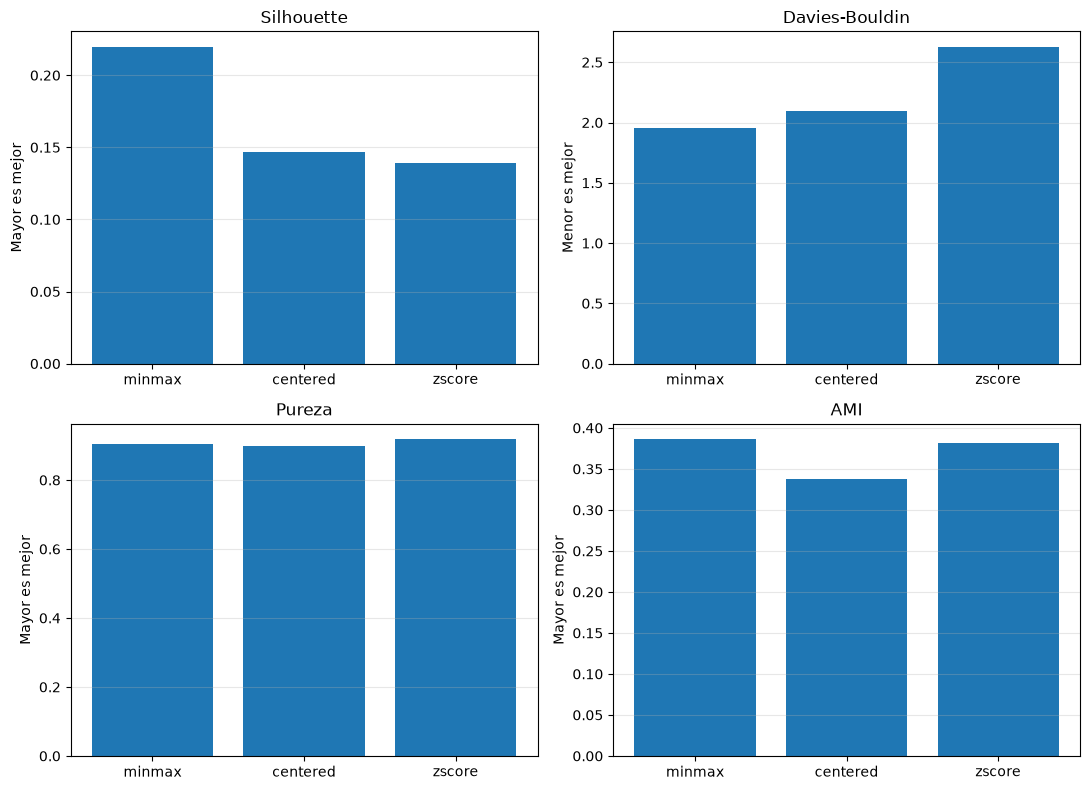

In [7]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(11, 8),
)

metricas_grafico = [
    (
        "silhouette_val",
        "Silhouette",
        "Mayor es mejor",
    ),
    (
        "davies_bouldin_val",
        "Davies-Bouldin",
        "Menor es mejor",
    ),
    (
        "purity_val",
        "Pureza",
        "Mayor es mejor",
    ),
    (
        "ami_val",
        "AMI",
        "Mayor es mejor",
    ),
]

for ax, (columna, titulo, criterio) in zip(
    axes.flat,
    metricas_grafico,
):
    ax.bar(
        df_resultados_normalizacion["normalizacion"],
        df_resultados_normalizacion[columna],
    )

    ax.set_title(titulo)
    ax.set_ylabel(criterio)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
CARPETA_SELECCION_AA = (
    PROJECT_ROOT
    / "resultados"
    / "seleccion_parametros_aa"
)

CARPETA_SELECCION_AA.mkdir(
    parents=True,
    exist_ok=True,
)

ruta_resultados_csv = (
    CARPETA_SELECCION_AA
    / "seleccion_normalizacion_aa.csv"
)

ruta_resultados_parquet = (
    CARPETA_SELECCION_AA
    / "seleccion_normalizacion_aa.parquet"
)

df_resultados_normalizacion.to_csv(
    ruta_resultados_csv,
    index=False,
)

df_resultados_normalizacion.to_parquet(
    ruta_resultados_parquet,
    index=False,
)

print("Normalización seleccionada: minmax")
print(f"Resultados CSV: {ruta_resultados_csv}")
print(f"Resultados Parquet: {ruta_resultados_parquet}")

Normalización seleccionada: minmax
Resultados CSV: c:\Users\adanm\Code\tesis\resultados\seleccion_parametros_aa\seleccion_normalizacion_aa.csv
Resultados Parquet: c:\Users\adanm\Code\tesis\resultados\seleccion_parametros_aa\seleccion_normalizacion_aa.parquet
